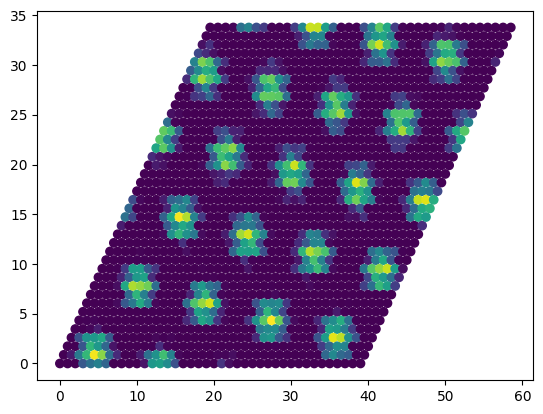

"\nhi indira & tristan & whoever else it concerns\nyoull have to run this jupyter notebook from beginning prob\ntips for jupyter notebook:\n1) keep track of what you ran. try NOT to run cells out of order.\n2) this may seem easier than normal coding but its actually like not. be careful.\n3) fyi ipynbs are 'modified' if code OR cell output changes\n"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random

from RunSimulator import RunSimulator
from PathPlotter import PathPlotter
master = RunSimulator()

"""
hi indira & tristan & whoever else it concerns
youll have to run this jupyter notebook from beginning prob
tips for jupyter notebook:
1) keep track of what you ran. try NOT to run cells out of order.
2) this may seem easier than normal coding but its actually like not. be careful.
3) fyi ipynbs are 'modified' if code OR cell output changes
"""

In [2]:
#baseline constants
baseline_trial_num = 10
error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim=20000
deltahead=2.4

#running trials!
random.seed(42) # NOTE: only set this when you want to RESET the module
master.baseline(baseline_trial_num, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim, deltahead=deltahead)
baseline_final_drifts = master.all_final_drift
baseline_mean_errors = master.all_mean_error
baseline_rmses = master.all_rmse
baseline_errors_over_time = master.all_error_over_time


the mouse moved this far: 324.8378051033331
[[-72.11040188 316.73283626]]
[-72.72942839 291.82497952]
the mouse moved this far: 645.4915509755027
[[-93.12732954 638.73832113]]
[-86.58856339 681.27835915]
the mouse moved this far: 830.8038755403552
[[334.79828485 760.35859177]]
[344.29144416 766.71265978]
the mouse moved this far: 590.563512381621
[[249.7969485  535.13245713]]
[256.57491963 572.09033771]
the mouse moved this far: 305.990081648238
[[223.24507229 209.26434901]]
[227.99111735 197.60919788]
the mouse moved this far: 695.1659687110055
[[618.37083717 317.60546561]]
[637.40521472 307.07121493]
the mouse moved this far: 612.8661508425307
[[-214.45005275 -574.12201989]]
[-229.88260361 -580.03546458]
the mouse moved this far: 1074.768999156258
[[ 327.52475643 1023.64834561]]
[ 356.02767278 1054.05243812]
the mouse moved this far: 372.04076090991634
[[187.47003748 321.35543068]]
[203.27985377 333.87061083]
the mouse moved this far: 423.6262484642674
[[379.17139363 188.91334691]]
[

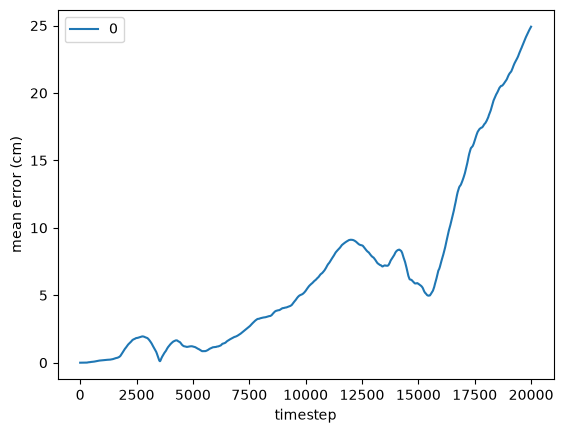

In [3]:
#plot error over time
x = np.arange(sim) # this only works now in this specific case bc error_freq=1
y = np.mean(baseline_errors_over_time, axis=0)
y_list = baseline_errors_over_time

#y=master.error_over_time_i
for i in range(1):
    plt.plot(x,y_list[i],label=i)
plt.xlabel('timestep')
plt.ylabel('mean error (cm)')
plt.legend()
plt.show()

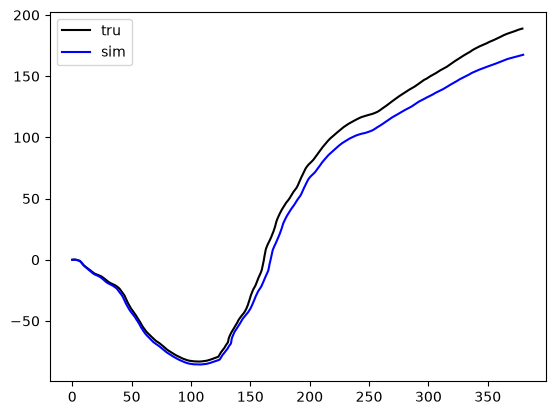

In [4]:
#plot true path vs sim path over time

pathplotter = PathPlotter()
path_array = np.zeros((2,sim,2))
path_array[0] = master.trimmed_og_pos
path_array[1] = master.trimmed_sim_pos
pathplotter.paths(path_array, colors=["black", "blue"],labels=["tru", "sim"])


In [58]:
#simulation time trial constants
simlen_trial_num = 3
simlen_iters = 10

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim_list=(np.arange(simlen_iters)+1)*10000
deltahead=2.4

#running trials!
sim_trial_final_drifts = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_mean_errors = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_rmses = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_errors_over_time = [] #NOT a numpy array. its a 3d one, iter x simlen trial_num x floor(simlen/errorfreq)

for i in range(simlen_iters):
    master.baseline(simlen_trial_num, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim_list[i], deltahead=deltahead)
    sim_trial_final_drifts[i] = master.all_final_drift
    sim_trial_mean_errors[i] = master.all_mean_error
    sim_trial_rmses[i] = master.all_rmse
    sim_trial_errors_over_time.append(master.all_error_over_time)

the mouse moved this far: 289.6050541980893
[[223.0651112  184.69716723]]
[232.09130971 199.47240091]
the mouse moved this far: 141.14603998639922
[[141.14270744   0.96991804]]
[148.57540864  -2.31050796]
the mouse moved this far: 147.50524205925373
[[131.0550861  -67.69313734]]
[133.62729249 -68.39892563]
the mouse moved this far: 854.0674886571686
[[853.95140527  14.08093081]]
[864.3379652  -37.62434213]
the mouse moved this far: 703.3479583064211
[[686.87826233 151.31623571]]
[708.56536432 130.71112778]
the mouse moved this far: 769.6306167126457
[[ 706.4463433  -305.39294396]]
[ 713.60086274 -333.36184298]
the mouse moved this far: 1063.007465588857
[[825.98591943 669.12788972]]
[844.824053   665.06484622]
the mouse moved this far: 547.1362663108324
[[546.15340635  32.78033928]]
[563.74186826  30.36663575]
the mouse moved this far: 233.79021403601186
[[-143.76654275  184.36118183]]
[-137.39024706  190.70340029]
the mouse moved this far: 674.040848880355
[[673.80171288  17.95320806]

In [59]:
print(sim_trial_final_drifts.shape)
print(sim_trial_mean_errors.shape)
print(sim_trial_rmses.shape)
print(f"{len(sim_trial_errors_over_time)}, {len(sim_trial_errors_over_time[0])}, {len(sim_trial_errors_over_time[0][0])}")

(10, 3)
(10, 3)
(10, 3)
10, 3, 10000


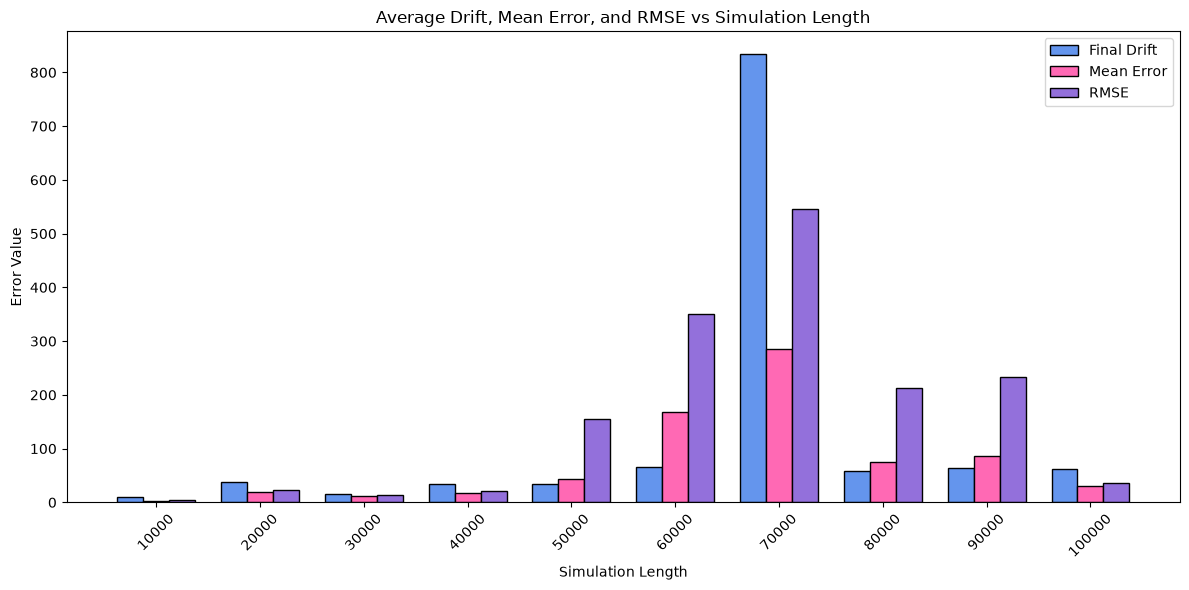

In [60]:
import matplotlib.pyplot as plt
import numpy as np

x_labels = [f"{(i + 1) * 10000}" for i in range(10)]
x_pos = np.arange(len(x_labels))

avg_final_drifts = np.mean(sim_trial_final_drifts, axis=1)
avg_mean_errors = np.mean(sim_trial_mean_errors, axis=1)
avg_rmses = np.mean(sim_trial_rmses, axis=1)

width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x_pos - width, avg_final_drifts, width, label="Final Drift", color="cornflowerblue", edgecolor="black")
plt.bar(x_pos, avg_mean_errors, width, label="Mean Error", color="hotpink", edgecolor="black")
plt.bar(x_pos + width, avg_rmses, width, label="RMSE", color="mediumpurple", edgecolor="black")

plt.xticks(x_pos, x_labels, rotation=45)
plt.xlabel("Simulation Length")
plt.ylabel("Error Value")
plt.title("Average Drift, Mean Error, and RMSE vs Simulation Length")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# module number trial . keep range the same from 25 cm to 22.6m
trial_count_per_condition = 3
permutations = np.arange(5, 15)
module_num_spacings = [np.power(2266./25., (1/i)) for i in permutations]

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim = 20000
deltahead=2.4

seeds = [
    'sophie likes 67', 'grid cells are cool', 'schizophrenia', 'sarah', 'sophie is going crazy', 'someone help her', 
    'her synaptic pruning is excessive', 'unlimited games', 'no games', 'unlimited bacon!'
]

assert len(permutations) == len(seeds)

#running trials!
module_num_final_drifts = np.zeros((len(permutations),trial_count_per_condition))
module_num_mean_errors = np.zeros((len(permutations),trial_count_per_condition))
module_num_rmses = np.zeros((len(permutations),trial_count_per_condition))
module_num_errors_over_time = [] #NOT a numpy array. its a 3d one, len x trial_num x floor(simlen/errorfreq)

for i in range(len(permutations)):
    random.seed(seeds[i])  # keeping the seed the same for all permutations gives the same errors across all module numbers
    # no can
    master.baseline(trial_count_per_condition, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim, deltahead=deltahead,
                    NUM_OF_MODS=permutations[i], spacing_min=25,scaling = module_num_spacings[i])
    module_num_final_drifts[i] = master.all_final_drift
    module_num_mean_errors[i] = master.all_mean_error
    module_num_rmses[i] = master.all_rmse
    module_num_errors_over_time.append(master.all_error_over_time)

the mouse moved this far: 607.0537156466282
[[581.2205321  175.20532738]]
[596.55010298 160.38613943]
the mouse moved this far: 216.8433850285335
[[ 30.52306739 214.68441021]]
[ 44.40394473 225.0761707 ]
the mouse moved this far: 626.2538651227616
[[  38.61780017 -625.06205219]]
[  26.24760232 -624.08588862]
the mouse moved this far: 1134.305947755511
[[759.12515984 842.83982749]]
[786.61961715 845.77428614]
the mouse moved this far: 1059.5509507539025
[[699.66111888 795.68997478]]
[737.01249258 787.1712022 ]
the mouse moved this far: 250.0722304919792
[[231.95640153 -93.44703447]]
[ 228.88347665 -101.22714371]
the mouse moved this far: 609.8390965771385
[[-555.41562612  251.82773076]]
[-579.54597507  274.26827611]
the mouse moved this far: 858.799571271904
[[ 498.63817953 -699.21146267]]
[ 506.25347083 -720.65450949]
the mouse moved this far: 1426.6067222764236
[[1421.96852854 -114.9445253 ]]
[1452.21845444 -162.03820654]
the mouse moved this far: 687.8324621816937
[[684.9059615   63.

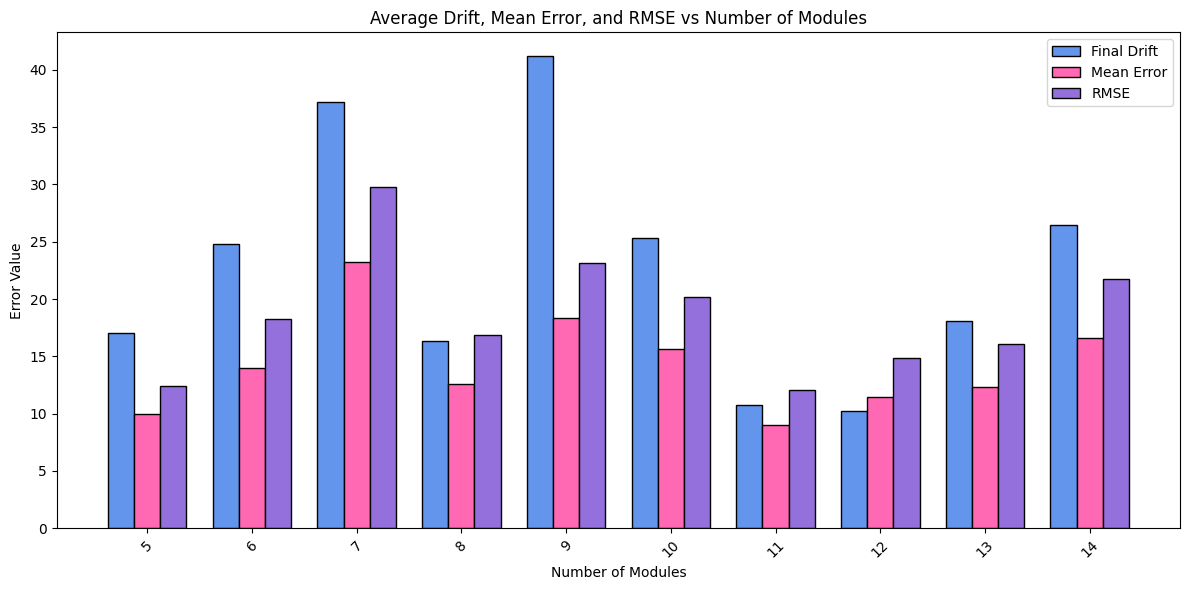

In [11]:
x_labels = permutations
x_pos = np.arange(len(x_labels))

avg_final_drifts = np.mean(module_num_final_drifts, axis=1)
avg_mean_errors = np.mean(module_num_mean_errors, axis=1)
avg_rmses = np.mean(module_num_rmses, axis=1)

width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x_pos - width, avg_final_drifts, width, label="Final Drift", color="cornflowerblue", edgecolor="black")
plt.bar(x_pos, avg_mean_errors, width, label="Mean Error", color="hotpink", edgecolor="black")
plt.bar(x_pos + width, avg_rmses, width, label="RMSE", color="mediumpurple", edgecolor="black")

plt.xticks(x_pos, x_labels, rotation=45)
plt.xlabel("Number of Modules")
plt.ylabel("Error Value")
plt.title("Average Drift, Mean Error, and RMSE vs Number of Modules")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# module spacing trial..... do tmrw sophie

# parameter = `scaling`

#simulation time trial constants
trial_count_per_condition = 5
permutations = np.arange(1.4, 1.70001, 0.1)

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim_list=(np.arange(permutations.size)+1)*10000
deltahead=2.4

seeds = ['sophie likes 67', 'grid cells are cool', 'schizophrenia', 'sarah']
assert len(permutations) == len(seeds)

#running trials!
canless_sim_trial_final_drifts = np.zeros((len(permutations),trial_count_per_condition))
canless_sim_trial_mean_errors = np.zeros((len(permutations),trial_count_per_condition))
canless_sim_trial_rmses = np.zeros((len(permutations),trial_count_per_condition))

for i in range(len(permutations)):
    random.seed(seeds[i])
    # no can
    master.baseline(trial_count_per_condition, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim_list[i], deltahead=deltahead, scaling=permutations[i])
    canless_sim_trial_final_drifts[i] = master.all_final_drift
    canless_sim_trial_mean_errors[i] = master.all_mean_error
    canless_sim_trial_rmses[i] = master.all_rmse


the mouse moved this far: 169.24201946899873
[[151.17952388 -76.07636107]]
[160.42339224 -81.41966096]
the mouse moved this far: 272.8463892319828
[[240.57885182 128.71273508]]
[247.55176379 131.04430383]
the mouse moved this far: 190.80490129175578
[[140.37769632 129.23085055]]
[146.1645686  135.16827208]
the mouse moved this far: 139.17731054414685
[[132.9280773   41.23651337]]
[142.35651519  42.43123191]
the mouse moved this far: 162.40849772700838
[[ 100.80405032 -127.33838217]]
[ 100.77114946 -141.33008678]
the mouse moved this far: 1134.305947755511
[[759.12515984 842.83982749]]
[786.61961715 845.77428614]
the mouse moved this far: 1059.5509507539025
[[699.66111888 795.68997478]]
[737.01249258 787.1712022 ]
the mouse moved this far: 250.0722304919792
[[231.95640153 -93.44703447]]
[ 228.88347665 -101.22714371]
the mouse moved this far: 817.7418194889175
[[567.23683714 589.01957008]]
[582.39735966 580.48426915]
the mouse moved this far: 732.0212995981803
[[729.69568862  58.3042458 